# Synthetic Point Clouds and Persistent Homology tests

Notebook to verify that the project enviroment is functioning correctly by computing the persisten homology of a sampled circle.

Expected results:
- Many connected components in \(H_0\) that gradually merge;
- One prominent \(H_1\) loop.

In [1]:
import sys 
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nCurrent working directory:")
print(Path.cwd())

Python executable:
C:\Users\Matteo Meyer\Projects\tda-time-series-classification\.venv\Scripts\python.exe

Current working directory:
C:\Users\Matteo Meyer\Projects\tda-time-series-classification\notebooks


In [2]:
import numpy as np 
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams

print("Scientific and TDA imports succesful")

Scientific and TDA imports succesful


## Sampled circles

Points are sampled evenly from the 2d unit circle.

In [3]:
n_points = 100
theta  = np.linspace(
    0.0,
    2.9 * np.pi,
    n_points,
    endpoint = False,
)
circle = np.column_stack(
    (
        np.cos(theta),
        np.sin(theta),
    )
)

print("Point-cloud shape: ", circle.shape)

Point-cloud shape:  (100, 2)


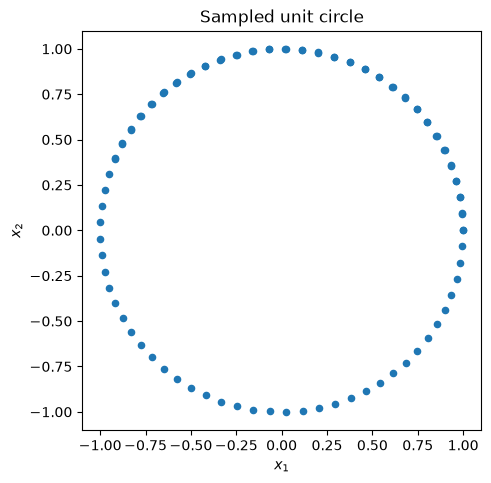

In [4]:
fig, ax = plt.subplots(figsize = (5, 5))

ax.scatter(
    circle[:, 0],
    circle[:, 1],
    s = 20,
)

ax.set_title("Sampled unit circle")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal")

fig.tight_layout()
plt.show()

## Vietoris-Rips persisten homology

We compute the persistent homology in dimensions 0 and 1 (H0 = connected components; H1 = loops).

In [5]:
results = ripser(
    circle, 
    maxdim = 1,
)

diagrams = results["dgms"]

print("numbers of diagrams:", len(diagrams))
print("H0 diagram shape:", diagrams[0].shape)
print("H1 diagram shape:", diagrams[1].shape)

numbers of diagrams: 2
H0 diagram shape: (100, 2)
H1 diagram shape: (1, 2)


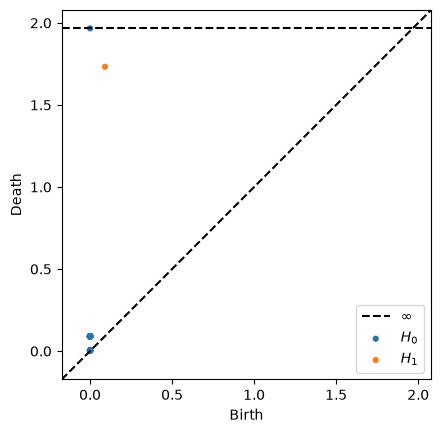

In [6]:
plot_diagrams(
    diagrams,
    show=True,
)

In [7]:
print("H0 persistence intervals:")
print(diagrams[0])

print("\nH1 persistence intervals:")
print(diagrams[1])

H0 persistence intervals:
[[0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]

In [8]:
h1_birth = diagrams[1][0, 0]
h1_death = diagrams[1][0, 1]
h1_persistence = h1_death - h1_birth

print("H1 birth:", h1_birth)
print("H1 death:", h1_death)
print("H1 persistence:", h1_persistence)

H1 birth: 0.09107468277215958
H1 death: 1.732574224472046
H1 persistence: 1.6414995416998863


In [9]:
assert len(diagrams) == 2
assert diagrams[1].shape[0] >= 1

print("Persistence check passed.")

Persistence check passed.
